# Binary suicide classification (RAG)

Binary head over `datasets/raw/suicide_detection_raw.csv` stratified subsets:
- **dev** — `datasets/processed/binary_suicide_dev.csv` (10/class = 20)
- **final** — `datasets/processed/binary_suicide_eval.csv` (150/class = 300)

Reuses the existing ICD-11 KB + BM25/Hybrid/Dense retrievers (no suicide KB / few-shot store yet).
Build subsets with: `python src/builders/build_binary_dataset.py`


In [1]:
# Path setup — works from repo root or notebooks/
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
root = None
for candidate in (_cwd, *_cwd.parents):
    if (candidate / "src" / "components" / "config.py").exists():
        root = candidate
        break
if root is None:
    raise RuntimeError(
        "Could not locate project root. Open this notebook from the repo or notebooks/ folder."
    )

sys.path.insert(0, str(root / "src"))
sys.path.insert(0, str(root / "src" / "retriever"))

from components.config import (
    PROJECT_ROOT,
    PDF_PATH,
    CHUNKS_PATH,
    CHROMA_PATH,
    BINARY_EVAL_SUBSET_PATH,
    BINARY_DEV_SLICE_PATH,
    BINARY_LABELS,
    BINARY_DATASET_PATH,
    RETRIEVAL_SECTIONS,
    MOOD_DISORDER_PREFIXES,
    RESULTS_DIR,
    BINARY_RESULTS_FINAL_PATH,
    BINARY_RESULTS_SUMMARY_PATH,
    BINARY_ERROR_ANALYSIS_PATH,
)

print("Project root:", PROJECT_ROOT)
print("PDF:         ", PDF_PATH, "| exists=", PDF_PATH.exists())
print("Chunks:      ", CHUNKS_PATH, "| exists=", CHUNKS_PATH.exists())
print("ChromaDB:    ", CHROMA_PATH, "| exists=", CHROMA_PATH.exists())
print("Binary eval: ", BINARY_EVAL_SUBSET_PATH, "| exists=", BINARY_EVAL_SUBSET_PATH.exists())
print("Binary dev:  ", BINARY_DEV_SLICE_PATH, "| exists=", BINARY_DEV_SLICE_PATH.exists())
print("Labels:      ", list(BINARY_LABELS))
print("Sections:    ", RETRIEVAL_SECTIONS)


Project root: /Users/sidemoctardialla/Desktop/AI-group-project-2026
PDF:          /Users/sidemoctardialla/Desktop/AI-group-project-2026/knowledge_base/icd_11/icd_11.pdf | exists= False
Chunks:       /Users/sidemoctardialla/Desktop/AI-group-project-2026/knowledge_base/icd_11/icd11_chunks.json | exists= True
ChromaDB:     /Users/sidemoctardialla/Desktop/AI-group-project-2026/knowledge_base/icd_11/chroma_db | exists= True
Binary eval:  /Users/sidemoctardialla/Desktop/AI-group-project-2026/datasets/processed/binary_suicide_eval.csv | exists= True
Binary dev:   /Users/sidemoctardialla/Desktop/AI-group-project-2026/datasets/processed/binary_suicide_dev.csv | exists= True
Labels:       ['suicide', 'non-suicide']
Sections:     ['Essential Features', 'Boundary with Normality']


# Imports

In [2]:
# CELL 2 — Imports

import json, csv, random, re, time, statistics, urllib.request, urllib.error
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from bm25_retriever import BM25Retriever
from hybrid_retriever import HybridRetriever
from dense_retriever import initialise_retrieval, DenseRetriever
from utils import load_chunks, filter_chunks_by_sections, filter_chunks_by_disorder_codes
import components.ingestion as ingestion

print("Imports OK.")


Imports OK.


# Configuration

In [3]:
# CELL 3 — Configuration
# Single dictionary controlling the entire experiment.

CFG = {
    # Ollama API settings
    "ollama_host":     "http://localhost:11434",
    "timeout_s":       1800,
    "num_predict":     512,
    "num_predict_think": 2048,   # thinking needs headroom for the trace + answer
    "num_ctx":         8192,   # Ollama context window (qwen3:0.6b/1.7b max 32768)
    "seed":            42,

    # Models to evaluate
    "models":          ["qwen3:0.6b", "qwen3:1.7b"],

    # Retriever settings (paths from components.config → knowledge_base/icd_11/)
    "knowledge_base":  str(CHUNKS_PATH),
    "retriever_types": ["bm25", "hybrid", "dense"],
    "top_k_values":    [1, 3, 5],
    "hybrid_alpha":    0.3,         # RRF weight: BM25 vs dense

    # Experiment variables
    "prompt_types":    ["zero_shot", "few_shot"],
    "thinking_modes":  [False, True],
    "debug_unknown": True,

    # Dataset mode:
    #   "dev"   -> binary_suicide_dev.csv  (20 posts) for prompt/k tuning / testing
    #   "final" -> binary_suicide_eval.csv (300 posts) for reported results
    "eval_mode":       "dev",
    "dataset_path_dev":   str(BINARY_DEV_SLICE_PATH),
    "dataset_path_final": str(BINARY_EVAL_SUBSET_PATH),
    "text_column":     "text",
    "label_column":    "label",
    "labels":          list(BINARY_LABELS),
    "positive_label":  "suicide",
}

if CFG["eval_mode"] == "dev":
    CFG["dataset_path"] = CFG["dataset_path_dev"]
elif CFG["eval_mode"] == "final":
    CFG["dataset_path"] = CFG["dataset_path_final"]
else:
    raise ValueError(f"CFG['eval_mode'] must be 'dev' or 'final', got {CFG['eval_mode']!r}")

print("Configuration loaded.")
print(f"  Eval mode:       {CFG['eval_mode']}")
print(f"  Models:          {CFG['models']}")
print(f"  Retrievers:      {CFG['retriever_types']}")
print(f"  Top-k values:    {CFG['top_k_values']}")
print(f"  Prompt types:    {CFG['prompt_types']}")
print(f"  Thinking modes:  {CFG['thinking_modes']}")
print(f"  Labels:          {CFG['labels']}")
print(f"  Dataset:         {CFG['dataset_path']}")
print(f"  Chunks KB:       {CFG['knowledge_base']}")
print(f"  Sections:        {RETRIEVAL_SECTIONS}")


Configuration loaded.
  Eval mode:       dev
  Models:          ['qwen3:0.6b', 'qwen3:1.7b']
  Retrievers:      ['bm25', 'hybrid', 'dense']
  Top-k values:    [1, 3, 5]
  Prompt types:    ['zero_shot', 'few_shot']
  Thinking modes:  [False, True]
  Labels:          ['suicide', 'non-suicide']
  Dataset:         /Users/sidemoctardialla/Desktop/AI-group-project-2026/datasets/processed/binary_suicide_dev.csv
  Chunks KB:       /Users/sidemoctardialla/Desktop/AI-group-project-2026/knowledge_base/icd_11/icd11_chunks.json
  Sections:        ['Essential Features', 'Boundary with Normality']


In [4]:
# CELL 3b — Run profile (edit QUICK_TEST / FINAL_REPORT)

QUICK_TEST = True   # True = small grid for end-to-end testing from this notebook
FINAL_REPORT = False  # True = full 450-post reporting set (disables QUICK_TEST)

if FINAL_REPORT:
    QUICK_TEST = False
    CFG["eval_mode"] = "final"
    CFG["dataset_path"] = CFG["dataset_path_final"]
    print("FINAL REPORT MODE — 300-post binary eval set; lock prompts before using this.")
elif QUICK_TEST:
    CFG["eval_mode"] = "dev"
    CFG["dataset_path"] = CFG["dataset_path_dev"]
    CFG["models"] = ["qwen3:0.6b"]
    CFG["retriever_types"] = ["bm25", "hybrid", "dense"]
    CFG["top_k_values"] = [3]
    CFG["prompt_types"] = ["zero_shot"]
    CFG["thinking_modes"] = [False]
    print("QUICK TEST MODE — binary dev slice (20), 1 model, 3 retrievers, k=3, zero-shot")
else:
    print("FULL DEV MODE — using CFG from Cell 3 as-is (eval_mode=" + CFG["eval_mode"] + ")")

print(f"  eval_mode={CFG['eval_mode']}")
print(f"  dataset={CFG['dataset_path']}")
print(f"  models={CFG['models']}")
print(f"  retrievers={CFG['retriever_types']}")
print(f"  top_k={CFG['top_k_values']}")
print(f"  prompts={CFG['prompt_types']}")
print(f"  thinking={CFG['thinking_modes']}")


QUICK TEST MODE — binary dev slice (20), 1 model, 3 retrievers, k=3, zero-shot
  eval_mode=dev
  dataset=/Users/sidemoctardialla/Desktop/AI-group-project-2026/datasets/processed/binary_suicide_dev.csv
  models=['qwen3:0.6b']
  retrievers=['bm25', 'hybrid', 'dense']
  top_k=[3]
  prompts=['zero_shot']
  thinking=[False]


# Prompt Builder

In [5]:
# CELL 4 — Prompt Builder (binary: suicide vs non-suicide)

SYSTEM_PROMPT = (
    "You are a mental-health risk classifier for social-media posts. "
    "Classify each post as suicide or non-suicide. "
    "You must reply with ONLY these two lines, nothing else:\n"
    "Label: <suicide|non-suicide>\n"
    "Reason: <one sentence>\n"
    "Do NOT give advice. Do NOT explain. Just the two lines above."
)

ZERO_SHOT_TEMPLATE = """\
{system}

Post: {post}

Answer:"""

FEW_SHOT_TEMPLATE = """\
{system}

Examples:
Post: "Had a long day at work but hanging out with friends tonight. Feeling okay overall."
Label: non-suicide — Everyday stress without suicidal content.

Post: "I don't see the point in living anymore. I've been thinking about ending it."
Label: suicide — Explicit passive or active suicidal ideation.

---
Post: {post}

Answer:"""

RETRIEVAL_BLOCK_TEMPLATE = """\

Relevant clinical knowledge:
{chunks}
---
"""

def build_prompt(post: str, prompt_type: str,
                 retrieved_chunks: list[dict], fewshot_examples=None) -> str:
    chunk_text = ""
    if retrieved_chunks:
        bullets = "\n".join(
            f"[{i+1}] ({c.get('disorder_name', '')} — {c.get('section', '')}): "
            f"{c.get('prompt_text', c.get('text', ''))}"
            for i, c in enumerate(retrieved_chunks)
        )
        chunk_text = RETRIEVAL_BLOCK_TEMPLATE.format(chunks=bullets)

    system = SYSTEM_PROMPT + chunk_text

    if prompt_type == "zero_shot":
        return ZERO_SHOT_TEMPLATE.format(system=system, post=post)

    # Few-shot: if `fewshot_examples` is provided, render them dynamically.
    # For now, callers don't pass any retrieved few-shot examples.
    if fewshot_examples:
        examples_block = "\n\n".join(
            f"Post: \"{ex.get('post', '')}\"\nLabel: {ex.get('label', '')}"
            for ex in fewshot_examples
        )
        dynamic_template = """\
{system}

Examples:
{examples}

---
Post: {post}

Answer:"""
        return dynamic_template.format(system=system, examples=examples_block, post=post)

    return FEW_SHOT_TEMPLATE.format(system=system, post=post)

print("Prompt builder ready (binary).")


Prompt builder ready (binary).


# Load Dataset

In [6]:
# CELL 5 — Load Dataset
# Loads the active eval file selected by CFG["eval_mode"]:
#   dev   -> binary_suicide_dev.csv  (20 stratified posts for tuning)
#   final -> binary_suicide_eval.csv (300 stratified posts for reporting)


def load_dataset(cfg: dict) -> pd.DataFrame:
    # We defined the csv field size limit because the default one is quite small
    csv.field_size_limit(10_000_000)
    path = cfg["dataset_path"]
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            text  = (r.get(cfg["text_column"])  or "").strip()
            label = (r.get(cfg["label_column"]) or "").strip().lower()
            # Skip rows with missing text or labels not in our valid label set
            if text and label in cfg["labels"]:
                row = {"text": text, "label": label}
                if r.get("row_id"):
                    row["row_id"] = r["row_id"]
                if r.get("parent_row_id"):
                    row["parent_row_id"] = r["parent_row_id"]
                rows.append(row)

    df = pd.DataFrame(rows)
    print(f"Eval mode: {cfg['eval_mode']}")
    print(f"Loaded from: {path}")
    print(f"Total usable rows: {len(df)}")
    print(df["label"].value_counts().to_string())
    return df.reset_index(drop=True)

df_posts = load_dataset(CFG)
df_posts.head()


Eval mode: dev
Loaded from: /Users/sidemoctardialla/Desktop/AI-group-project-2026/datasets/processed/binary_suicide_dev.csv
Total usable rows: 20
label
suicide        10
non-suicide    10


,text,label,row_id,parent_row_id
0,"'Use this time wisely, it won't happen again'Y...",suicide,bdev_0000,bin_0000
1,How do I help my suicidal friend?Im currently ...,suicide,bdev_0001,bin_0030
2,I did the last thing I needed to do before I d...,suicide,bdev_0002,bin_0039
3,I honestly just feel really hopeless. I don't ...,suicide,bdev_0003,bin_0057
4,I really wish I didn't have anyone at all who ...,suicide,bdev_0004,bin_0067


# Build Retrievers

In [ ]:
import components.ingestion as ingestion    
print("embedding model:", ingestion._embedding_model)    
print("collection:", ingestion._collection)    

embedding model: None
collection: None


In [8]:
def build_retrievers(cfg: dict) -> dict:
    kb = cfg["knowledge_base"]
    print(f"Building retrievers from: {kb}")
    assert Path(kb).exists(), f"Knowledge base not found at {kb}"

    # Restrict retrieval to mood-disorder ICD-11 content (6A6–6A8).
    # Without this, section filtering still leaves ~330 non-mood chunks
    # (substance use, PTSD, etc.) that pollute suicide/depression risk classification.
    all_chunks = load_chunks(kb)
    mood_chunks = filter_chunks_by_disorder_codes(all_chunks, MOOD_DISORDER_PREFIXES)
    mood_chunks = filter_chunks_by_sections(mood_chunks, RETRIEVAL_SECTIONS)
    print(
        f"Mood-disorder retrieval pool: {len(mood_chunks)} chunks "
        f"(from {len(all_chunks)} total)"
    )

    print(f"ChromaDB path: {CHROMA_PATH}")
    initialise_retrieval(chroma_path=str(CHROMA_PATH))

    retrievers = {}

    print("  → BM25   ...", end=" ", flush=True)
    retrievers["bm25"] = BM25Retriever(
        chunks=mood_chunks,
        sections=RETRIEVAL_SECTIONS,
    )

    print("  → Hybrid ...", end=" ", flush=True)
    retrievers["hybrid"] = HybridRetriever(
        chunks=mood_chunks,
        alpha=cfg["hybrid_alpha"],
        sections=RETRIEVAL_SECTIONS,
    )

    print("  → Dense ...", end=" ", flush=True)
    retrievers["dense"] = DenseRetriever(
        sections=RETRIEVAL_SECTIONS,
        json_path=kb,
    )

    print("\nAll retrievers ready.")
    return retrievers

retrievers = build_retrievers(CFG)


Building retrievers from: /Users/sidemoctardialla/Desktop/AI-group-project-2026/knowledge_base/icd_11/icd11_chunks.json
Mood-disorder retrieval pool: 28 chunks (from 1569 total)
ChromaDB path: /Users/sidemoctardialla/Desktop/AI-group-project-2026/knowledge_base/icd_11/chroma_db
Loading embedding model on cpu …
Ready. Collection 'icd11_clinical' has 1569 vectors.
  → BM25   ... BM25 retriever ready: 28 chunks indexed
  → Hybrid ... BM25 retriever ready: 28 chunks indexed
  → Dense ... 
All retrievers ready.


In [9]:
# Runs a quick sanity check on all three retrievers using a sample depression post.
# Verifies each retriever loads correctly, returns results, and that chunk fields
# (disorder_name, section, text/prompt_text) are present and non-empty.
# Run this cell after build_retrievers() succeeds and before the experiment grid.

TEST_QUERY = (
    "I don't want to be alive anymore. I've been planning how to end it "
    "and I don't see any reason to keep going."
)
TEST_K = 3

print("Test query:", TEST_QUERY[:80], "...")
print()
print("=" * 70)

all_passed = True

for name, retriever in retrievers.items():
    print()
    print("[" + name.upper() + "]")
    try:
        results = retriever.search(TEST_QUERY, k=TEST_K)

        if not results:
            print("  WARN  - returned 0 results (is the knowledge base populated?)")
            all_passed = False
        else:
            print("  OK    - returned", len(results), "chunk(s)")
            for i, chunk in enumerate(results):
                disorder = chunk.get("disorder_name", chunk.get("disorder_code", "<no disorder>"))
                section  = chunk.get("section", "<no section>")
                text     = chunk.get("prompt_text", chunk.get("text", ""))
                score = chunk.get("score", chunk.get("bm25_score", chunk.get("dense_score", None)))
                score_str = ("  score=" + "{:.4f}".format(score)) if score is not None else ""
                # Hybrid RRF results also expose per-retriever ranks.
                rank_str = ""
                if "bm25_rank" in chunk or "dense_rank" in chunk:
                    rank_str = (
                        "  bm25_rank=" + str(chunk.get("bm25_rank"))
                        + "  dense_rank=" + str(chunk.get("dense_rank"))
                    )
                print("  [" + str(i + 1) + "] " + str(disorder) + " - " + str(section) + score_str + rank_str)
                print("       " + str(text).strip())

            missing_fields = []
            for field in ["disorder_name", "section"]:
                if not any(c.get(field) for c in results):
                    missing_fields.append(field)
            if not any(c.get("prompt_text") or c.get("text") for c in results):
                missing_fields.append("text/prompt_text")
            if missing_fields:
                print("  WARN  - these fields are missing or empty:", missing_fields)
                print("         build_prompt() will format chunks without them.")
                all_passed = False
            else:
                print("  PASS  - all expected chunk fields present")

    except Exception as e:
        print("  FAIL  -", type(e).__name__ + ":", str(e))
        all_passed = False

print()
print("=" * 70)
if all_passed:
    print("ALL RETRIEVERS PASSED - safe to proceed to experiment grid.")
else:
    print("ONE OR MORE CHECKS FAILED - review warnings above before running the grid.")


Test query: I don't want to be alive anymore. I've been planning how to end it and I don't s ...


[BM25]
  OK    - returned 4 chunk(s)
  [1] Mood disorder, unspecified - Essential Features  score=3.2716
       from one idea to the next; the person reports that their thoughts are rapid or even racing and has difficulty remaining on a topic); • increased self-esteem or grandiosity (e.g. the individual is more self-confident than usual); • decreased need for sleep (e.g. the person reports needing less sleep than usual and still feels well-rested), as distinct from insomnia, in which an individual wants to sleep but cannot; • distractibility (e.g. the person has difficulty staying on task, because attention is drawn to irrelevant or minor environmental stimuli, such as being overly distracted by outside noise during a conversation); Mood disorders 223 • impulsive reckless behaviour (e.g. the individual pursues pleasurable activities with little regard to their potential for negative conse

# Ollama Helpers

In [10]:
# CELL 7 — Ollama Helpers
# In this cell we defines the functions that will help us communicate with Ollama API

# Sends a POST request to Ollama and returns the response
def _http_post(host: str, path: str, payload: dict, timeout: int) -> dict:
    # Sends a JSON POST request to the Ollama API and returns the parsed response
    req = urllib.request.Request(
        host + path,
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode())

# Confirms Ollama is running and required models are pulled
def check_ollama(cfg: dict) -> list[str]:
    req = urllib.request.Request(cfg["ollama_host"] + "/api/tags")
    with urllib.request.urlopen(req, timeout=10) as r:
        data = json.loads(r.read().decode())
    installed = [m["name"] for m in data.get("models", [])]
    print("Ollama is running. Installed models:")
    for m in installed:
        print(f"  {m}")
    missing = [m for m in cfg["models"]
               if not any(i == m or i.startswith(m) for i in installed)]
    if missing:
        print(f"\nWARNING — these models are not pulled yet: {missing}")
        print("Run:  ollama pull <model>  for each one before the grid sweep.")
    return installed

installed_models = check_ollama(CFG)

#  Extracts the classification label from the model's output
# def _parse_label(text: str, valid_labels: list[str]) -> str:
#     # Parse only the model answer — not retrieved ICD text that may contain
#     # depression / suicide in a clinical sense unrelated to the predicted label.
#     answer = text.strip().splitlines()[0] if text.strip() else ""
#     match = re.search(r"label:\s*(\w+)", answer.lower())
#     if match and match.group(1) in valid_labels:
#         return match.group(1)
#     # Fallback: whole-word match on the first line only (longest label first).
#     for label in sorted(valid_labels, key=len, reverse=True):
#         if re.search(rf"\b{re.escape(label)}\b", answer.lower()):
#             return label
#     return "unknown"
LABEL_ALIASES = {
    "suicide": "suicide",
    "suicidal": "suicide",
    "suicidality": "suicide",
    "suicidal_ideation": "suicide",
    "self-harm": "suicide",
    "self_harm": "suicide",
    "non-suicide": "non-suicide",
    "nonsuicide": "non-suicide",
    "non_suicide": "non-suicide",
    "not-suicide": "non-suicide",
    "not_suicide": "non-suicide",
    "normal": "non-suicide",
    "none": "non-suicide",
    "healthy": "non-suicide",
    "depression": "non-suicide",
    "depressed": "non-suicide",
}

def _parse_label(text: str, valid_labels: list[str]) -> str:
    if not text.strip():
        return "unknown"
    lines = text.strip().splitlines()
    # 1. Explicit "Label: X" anywhere in the answer
    m = re.search(r"label\s*[:\-]\s*([a-z_\- ]+)", text.lower())
    if m:
        cand = m.group(1).strip().split()[0].strip(".,;*")
        if cand in LABEL_ALIASES:
            return LABEL_ALIASES[cand]
    # 2. Whole-word alias match on the first line
    first = lines[0].lower()
    for alias, canon in sorted(LABEL_ALIASES.items(), key=lambda x: -len(x[0])):
        if re.search(rf"\b{re.escape(alias)}\b", first):
            return canon
    return "unknown"

# Separates the thinking trace from the actual answer
def _split_thinking(response_text: str, thinking_field: str) -> tuple[str, str]:
    # Newer Ollama versions return thinking in a separate field
    if thinking_field:
        return thinking_field.strip(), response_text.strip()
    # Older versions embed thinking inline as <think>...</think> tags
    m = re.search(r"<think>(.*?)</think>", response_text, re.DOTALL)
    if m:
        return m.group(1).strip(), response_text[m.end():].strip()
    # Thinking mode was off — return empty thinking and full response as answer
    return "", response_text.strip()

# Sends a prompt to a model and returns timing + output
def call_ollama(prompt: str, model: str, think: bool, cfg: dict) -> dict:
    # Builds the request payload and sends it to Ollama
    payload = {
        "model":  model,
        "prompt": prompt,
        "think":  think,   # toggles Qwen3 thinking/reasoning mode
        "stream": False,   # wait for full response before returning
        "options": {
            "seed":        cfg["seed"],        # fixed for reproducibility
            "temperature": 0.0,
            "top_p": 1.0,
            "num_predict": cfg["num_predict_think"] if think else cfg["num_predict"], # max tokens to generate
            "num_ctx":     cfg.get("num_ctx", 8192),  # context window size
        },
    }
    t0 = time.perf_counter()
    resp = _http_post(cfg["ollama_host"], "/api/generate", payload, cfg["timeout_s"])
    wall_s = time.perf_counter() - t0

    raw_response   = resp.get("response", "")
    thinking_field = resp.get("thinking", "") or ""
    thinking_text, answer_text = _split_thinking(raw_response, thinking_field)

    gen_eval_s = resp.get("eval_duration", 0) / 1e9
    gen_tokens  = resp.get("eval_count", 0)

    return {
        "wall_s":        round(wall_s, 3),
        "total_s":       round(resp.get("total_duration", 0) / 1e9, 3),
        "prompt_tokens": resp.get("prompt_eval_count", 0),
        "gen_tokens":    gen_tokens,
        "tok_per_s":     round(gen_tokens / gen_eval_s, 2) if gen_eval_s else 0.0,
        "thinking_text": thinking_text,
        "answer_text":   answer_text,
        "hit_cap":       gen_tokens >= cfg["num_predict"], # True if model hit the token limit
    }

print("Ollama helpers ready.")


Ollama is running. Installed models:
  qwen3:8b
  qwen3:4b
  qwen3:1.7b
  qwen3:0.6b
  llama3.1:8b
  nomic-embed-text:latest
Ollama helpers ready.


# Pipeline Runner

In [11]:
# CELL 8 — Pipeline Runner
# run_single() is the core of the pipeline. It takes one post and one
# experiment configuration, runs it through the full RAG pipeline, and
# returns a results dict with the prediction, timing, and retrieved chunks.
# Called once per post per configuration in the experiment grid.
# strategy controls retrieval shape: "expand" = disorder-aware seed-and-expand
# (retrieve seeds, then add every allowed section for each seed disorder);
# "flat" = plain top-k; "none" = no retrieval (k=0 baseline).


def run_single(
    post: str,
    true_label: str,
    model: str,
    retriever_type: str,
    top_k: int,
    prompt_type: str,
    think: bool,
    retrievers: dict,
    cfg: dict,
    strategy: str = "expand",
) -> dict:

    # Step 1 — Retrieve top-k relevant CDDR chunks for this post
    t_ret = time.perf_counter()
    if top_k <= 0:
        chunks = []  # no-retrieval baseline (RQ5)
        strategy = "none"
    else:
        chunks = retrievers[retriever_type].search(
            post, k=top_k, expand=(strategy == "expand")
        )
    retrieval_s = round(time.perf_counter() - t_ret, 4)

    # Step 2 — Assemble the prompt (system + retrieved chunks + post)
    prompt = build_prompt(post, prompt_type, chunks)

    # Step 3 — Send prompt to the LLM and get response + timing
    llm_out = call_ollama(prompt, model, think, cfg)

    # Step 4 — Extract the predicted label from the model's raw output
    predicted = _parse_label(llm_out["answer_text"], cfg["labels"])

    # Diagnostic: surface parse failures instead of letting them score as wrong
    if predicted == "unknown" and cfg.get("debug_unknown", True):
        print(f"    [UNKNOWN PARSE] true={true_label} | hit_cap={llm_out['hit_cap']}")
        print(f"      raw: {llm_out['answer_text'][:200]!r}")

    return {
        # Experiment configuration axes
        "model":           model,
        "retriever":       retriever_type,
        "top_k":           top_k,
        "prompt_type":     prompt_type,
        "think":           think,
        "strategy":        strategy,
        # Ground truth and prediction
        "true_label":      true_label,
        "predicted":       predicted,
        "correct":         int(predicted == true_label),
        # Timing
        "retrieval_s":     retrieval_s,
        "llm_total_s":     llm_out["total_s"],
        "tok_per_s":       llm_out["tok_per_s"],
        "prompt_tokens":   llm_out["prompt_tokens"],
        "gen_tokens":      llm_out["gen_tokens"],
        "hit_cap":         llm_out["hit_cap"],
        # Retrieved evidence (kept for retrieval quality analysis)
        "chunks_returned": len(chunks),
        "chunk_ids": [c.get("id", c.get("disorder_code", "")) for c in chunks],
        # Raw model output (kept for error analysis)
        "answer_text":     llm_out["answer_text"],
        "thinking_text":   llm_out["thinking_text"],
    }

print("run_single() defined.")

run_single() defined.


In [12]:
# CELL 9 — Model Warmup
# Sends one dummy call to each model before the timed experiment grid.
# Without this, the first real post would be slower than the rest because
# Ollama needs to load the model weights into RAM on the first call.
# Warmup results are discarded — only used to pre-load the model.

print("Warming up models (one call each, results discarded) ...")
for model in CFG["models"]:
    try:
        call_ollama("Hello", model, False, CFG)
        print(f"  ✓ {model}")
    except Exception as e:
        print(f"  ✗ {model}  — {e}")
print("Warmup done.")

Warming up models (one call each, results discarded) ...
  ✓ qwen3:0.6b
Warmup done.


In [13]:
# CELL 10 — Full Experiment Grid (COMMENTED OUT — use Cell 12 instead)
# Runs every possible combination of all CFG variables using itertools.product.
# With current CFG this produces:
#   2 models × 3 retrievers × 4 top-k × 2 prompt types × 2 thinking modes
#   = 96 configurations × 50 posts = 4800 LLM calls
# Estimated time on CPU: many hours — not practical for development.
# Use the targeted grid in Cell 12 which runs ~1000 calls instead.


# # Build all combinations of experiment variables into a flat list of tuples
# grid = list(product(
#     CFG["models"],
#     CFG["retriever_types"],
#     CFG["top_k_values"],
#     CFG["prompt_types"],
#     CFG["thinking_modes"],
# ))
# total_calls = len(grid) * len(df_posts)
# print(f"Grid size: {len(grid)} configurations × {len(df_posts)} posts = {total_calls} LLM calls")
# print("This will take a while on CPU. Consider reducing models/top_k_values/sample_size for dev runs.\n")
#
# # Loop over every configuration, then every post within each configuration
# all_results = []
# for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
#     config_label = (f"{model} | {retriever_type} | k={top_k} | "
#                     f"{prompt_type} | think={think}")
#     print(f"\n[{config_idx+1}/{len(grid)}] {config_label}")
#
#     for post_idx, row in df_posts.iterrows():
#         try:
#             # Run one post through the full pipeline for this configuration
#             result = run_single(
#                 post          = row["text"],
#                 true_label    = row["label"],
#                 model         = model,
#                 retriever_type= retriever_type,
#                 top_k         = top_k,
#                 prompt_type   = prompt_type,
#                 think         = think,
#                 retrievers    = retrievers,
#                 cfg           = CFG,
#             )
#             all_results.append(result)
#             status = "✓" if result["correct"] else "✗"
#             print(f"  {status} post{post_idx:02d} | "
#                   f"true={result['true_label']:8} pred={result['predicted']:8} | "
#                   f"llm={result['llm_total_s']:.1f}s  ret={result['retrieval_s']:.3f}s")
#         except Exception as e:
#             # Log errors per post without stopping the whole run
#             print(f"  ERROR post{post_idx}: {e}")
#
# # Save all results to CSV and display first few rows
# df_results = pd.DataFrame(all_results)
# df_results.to_csv("rag_results_raw.csv", index=False)
# print(f"\nDone. {len(df_results)} rows saved to rag_results_raw.csv")
# df_results.head()

# Experiment

In [14]:
# CELL 11 — Targeted Experiment Grid
# Runs a targeted grid answering seven research questions (RQs), each
# isolating one variable while keeping the others fixed.
# Grid tuple: (model, retriever, top_k, prompt_type, think, strategy)

grid = []

# RQ1: How does top-k affect BM25 classification accuracy?
for k in [1, 3, 5, 7]:
    grid.append(("qwen3:0.6b", "bm25", k, "zero_shot", False, "expand"))

# RQ2: Does model size affect BM25 classification accuracy?
for model in ["qwen3:0.6b", "qwen3:1.7b"]:
    grid.append((model, "bm25", 5, "zero_shot", False, "expand"))

# RQ3: Does thinking mode improve BM25 accuracy?
grid.append(("qwen3:0.6b", "bm25", 5, "zero_shot", True, "expand"))

# RQ4: Does few-shot prompting improve BM25 over zero-shot?
grid.append(("qwen3:0.6b", "bm25", 5, "few_shot", False, "expand"))

# RQ5: Does RAG actually help? (no-retrieval baseline)
grid.append(("qwen3:0.6b", "bm25", 0, "zero_shot", False, "none"))

# RQ6: Which retriever performs best? (H3 — BM25 vs dense vs hybrid)
# Fixed k=5, zero-shot, 0.6b — only the retriever varies.
for ret in ["bm25", "dense", "hybrid"]:
    grid.append(("qwen3:0.6b", ret, 5, "zero_shot", False, "expand"))

# RQ7: Does disorder-aware seed-and-expand beat flat top-k? (H2)
# Same config as RQ2's 0.6b row but with expansion off — the pair isolates
# the contribution of section expansion at identical k.
grid.append(("qwen3:0.6b", "bm25", 5, "zero_shot", False, "flat"))

# Several RQs share the 0.6b/bm25/k=5/zero_shot/False/expand config.
# Deduplicate so it isn't run multiple times and averaged against itself.
seen = set()
grid = [g for g in grid if not (g in seen or seen.add(g))]

# Print the full grid before running so it can be reviewed
posts_to_run = df_posts  # full active set (dev=30 or final=450)
total_calls = len(grid) * len(posts_to_run)
out_file = str(BINARY_RESULTS_FINAL_PATH)

print(f"Grid: {len(grid)} configs × {len(posts_to_run)} posts = {total_calls} calls")
print(f"Output: {out_file}")
print(f"Est. time: ~{total_calls * 0.5 / 60:.1f} min\n")
for i, (m, r, k, p, t, s) in enumerate(grid):
    print(f"  [{i+1:2d}] {m:14} {r:8} k={k} {p:10} think={t} strategy={s}")

# Run the grid — try/finally ensures partial results are saved even if
# the run crashes or is interrupted halfway through
all_results = []
try:
    for config_idx, (model, retriever_type, top_k, prompt_type, think, strategy) in enumerate(grid):
        label = (f"{model} | {retriever_type} | k={top_k} | {prompt_type} | "
                 f"think={think} | {strategy}")
        print(f"\n[{config_idx+1}/{len(grid)}] {label}")

        for post_idx, row in posts_to_run.iterrows():
            try:
                result = run_single(
                    post=row["text"], true_label=row["label"],
                    model=model, retriever_type=retriever_type,
                    top_k=top_k, prompt_type=prompt_type,
                    think=think, retrievers=retrievers, cfg=CFG,
                    strategy=strategy,
                )
                all_results.append(result)
                s = "✓" if result["correct"] else "✗"
                print(f"  {s} post{post_idx:02d} | true={result['true_label']:8} pred={result['predicted']:8} | llm={result['llm_total_s']:.1f}s")
            except Exception as e:
                # Log errors per post without stopping the whole run
                print(f"  ERROR post{post_idx}: {e}")

finally:
    # Always save whatever results were collected — even on crash or interrupt
    if all_results:
        df_results = pd.DataFrame(all_results)
        df_results.to_csv(out_file, index=False)
        print(f"\nSaved {len(df_results)} rows to {out_file}")

Grid: 11 configs × 20 posts = 220 calls
Output: /Users/sidemoctardialla/Desktop/AI-group-project-2026/results/binary_rag_results.csv
Est. time: ~1.8 min

  [ 1] qwen3:0.6b     bm25     k=1 zero_shot  think=False strategy=expand
  [ 2] qwen3:0.6b     bm25     k=3 zero_shot  think=False strategy=expand
  [ 3] qwen3:0.6b     bm25     k=5 zero_shot  think=False strategy=expand
  [ 4] qwen3:0.6b     bm25     k=7 zero_shot  think=False strategy=expand
  [ 5] qwen3:1.7b     bm25     k=5 zero_shot  think=False strategy=expand
  [ 6] qwen3:0.6b     bm25     k=5 zero_shot  think=True strategy=expand
  [ 7] qwen3:0.6b     bm25     k=5 few_shot   think=False strategy=expand
  [ 8] qwen3:0.6b     bm25     k=0 zero_shot  think=False strategy=none
  [ 9] qwen3:0.6b     dense    k=5 zero_shot  think=False strategy=expand
  [10] qwen3:0.6b     hybrid   k=5 zero_shot  think=False strategy=expand
  [11] qwen3:0.6b     bm25     k=5 zero_shot  think=False strategy=flat

[1/11] qwen3:0.6b | bm25 | k=1 | zer

In [15]:
# # CELL 11a — Smoke Test Grid (TEMPORARY — remove with Cell 3b)
# # Runs a single configuration on 5 posts to confirm the pipeline works
# # end-to-end before committing to the full experiment grid.
# # REMOVE THIS CELL once real ICD-11 CDDR chunks are ready and replace
# # with Cell 12 (targeted grid) for the actual experiment run.


# grid = [("qwen3:0.6b", "bm25", 3, "zero_shot", False)]
# posts_to_run = df_posts  # already limited to 5 by CFG override in Cell 4

# total_calls = len(grid) * len(posts_to_run)
# print(f"Smoke test: {len(grid)} config × {len(posts_to_run)} posts = {total_calls} LLM calls")

# all_results = []
# for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
#     print(f"\n[{config_idx+1}/{len(grid)}] {model} | {retriever_type} | k={top_k} | {prompt_type} | think={think}")

#     for post_idx, row in posts_to_run.iterrows():
#         try:
#             result = run_single(
#                 post=row["text"], true_label=row["label"],
#                 model=model, retriever_type=retriever_type,
#                 top_k=top_k, prompt_type=prompt_type,
#                 think=think, retrievers=retrievers, cfg=CFG,
#             )
#             all_results.append(result)
#             s = "✓" if result["correct"] else "✗"
#             print(f"  {s} post{post_idx:02d} | true={result['true_label']:8} pred={result['predicted']:8} | llm={result['llm_total_s']:.1f}s")
#         except Exception as e:
#             print(f"  ERROR post{post_idx}: {e}")

# df_results = pd.DataFrame(all_results)
# print(f"\nDone. {len(df_results)} rows saved.")
# df_results.head()

In [16]:
# CELL 13 — Results Summary
# Aggregates raw results into a summary table grouped by experiment variables.
# For each configuration computes:
#   n          — number of posts evaluated
#   accuracy   — proportion of correct predictions
#   macro_f1   — macro-averaged F1 across all three labels (main metric)
#                macro-F1 is preferred over accuracy here because it treats
#                all classes equally regardless of their size in the sample
#   mean_llm_s — average LLM inference time per post
#   mean_ret_s — average retrieval time per post

def summarise(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    records = []
    for keys, grp in df.groupby(group_cols):
        # groupby returns a scalar when grouping by one column, tuple for multiple
        if not isinstance(keys, tuple):
            keys = (keys,)
        rec = dict(zip(group_cols, keys))
        rec["n"]        = len(grp)
        rec["accuracy"] = round(grp["correct"].mean(), 4)
        rec["unknown_rate"] = round((grp["predicted"] == "unknown").mean(), 4)
        # macro-F1 requires predictions for all labels to be meaningful —
        # use try/except to handle edge cases where a label has no predictions
        try:
            rec["macro_f1"] = round(
                f1_score(grp["true_label"], grp["predicted"],
                         labels=CFG["labels"], average="macro",
                         zero_division=0), 4)
            rec["suicide_f1"] = round(
                f1_score(grp["true_label"], grp["predicted"],
                         labels=CFG["labels"], average="binary",
                         pos_label=CFG["positive_label"],
                         zero_division=0), 4)
        except Exception:
            rec["macro_f1"] = float("nan")
            rec["suicide_f1"] = float("nan")
        rec["mean_llm_s"] = round(grp["llm_total_s"].mean(), 2)
        rec["mean_ret_s"] = round(grp["retrieval_s"].mean(), 4)
        records.append(rec)
    # Sort by macro_f1 descending so best configurations appear first
    return pd.DataFrame(records).sort_values("macro_f1", ascending=False)

# Summarise at the full configuration level — one row per unique combination
# of model, retriever, top_k, prompt_type, and thinking mode
df_summary = summarise(
    df_results,
    ["model", "retriever", "top_k", "prompt_type", "think", "strategy"]
)
print("Top 10 configurations by macro-F1 (also shows suicide_f1):")
df_summary.head(10)


Top 10 configurations by macro-F1 (also shows suicide_f1):


,model,retriever,top_k,prompt_type,think,strategy,n,accuracy,unknown_rate,macro_f1,suicide_f1,mean_llm_s,mean_ret_s
9,qwen3:0.6b,hybrid,5,zero_shot,False,expand,20,0.8500,0.0,0.8465,0.8235,2.35,0.1160
8,qwen3:0.6b,dense,5,zero_shot,False,expand,20,0.8000,0.0,0.7917,0.7500,2.68,0.1292
1,qwen3:0.6b,bm25,1,zero_shot,False,expand,20,0.7500,0.0,0.7333,0.8000,0.53,0.0022
3,qwen3:0.6b,bm25,5,few_shot,False,expand,20,0.7000,0.0,0.6970,0.7273,0.93,0.0029
5,qwen3:0.6b,bm25,5,zero_shot,False,flat,20,0.6500,0.0,0.6491,0.6667,1.83,0.0021
7,qwen3:0.6b,bm25,7,zero_shot,False,expand,20,0.6000,0.0,0.6000,0.6000,0.69,0.0021
4,qwen3:0.6b,bm25,5,zero_shot,False,expand,20,0.5500,0.0,0.5489,0.5714,0.85,0.0024
2,qwen3:0.6b,bm25,3,zero_shot,False,expand,20,0.5500,0.0,0.5396,0.4706,0.76,0.0025
10,qwen3:1.7b,bm25,5,zero_shot,False,expand,18,0.5556,0.0,0.3571,0.0000,2.77,0.0025
0,qwen3:0.6b,bm25,0,zero_shot,False,none,20,0.5000,0.0,0.3333,0.6667,0.57,0.0000


In [17]:
# CELL 14 — Per-Axis Summary
# Breaks down results by each experimental variable independently.
# Each axis answers one research question by averaging across all other variables:
#   Model size     → does 1.7b outperform 0.6b?
#   Retriever type → BM25-only in this version.
#   Top-k          → how many retrieved chunks gives the best F1?
#   Prompt type    → does few-shot improve over zero-shot?
#   Thinking mode  → does thinking ON improve accuracy?

axes = {
    "Model size":    ["model"],
    "Retriever type":["retriever"],
    "Top-k":         ["top_k"],
    "Prompt type":   ["prompt_type"],
    "Thinking mode": ["think"],
    "Strategy":      ["strategy"],
}

# Print a summary table for each axis — sorted by macro_f1 descending
for axis_name, cols in axes.items():
    print(f"\n── {axis_name} ─────────────────────────────")
    print(summarise(df_results, cols).to_string(index=False))


── Model size ─────────────────────────────
     model   n  accuracy  unknown_rate  macro_f1  suicide_f1  mean_llm_s  mean_ret_s
qwen3:1.7b  18    0.5556        0.0000    0.3571         0.0        2.77      0.0025
qwen3:0.6b 199    0.6633        0.0101       NaN         NaN        2.07      0.0263

── Retriever type ─────────────────────────────
retriever   n  accuracy  unknown_rate  macro_f1  suicide_f1  mean_llm_s  mean_ret_s
   hybrid  20    0.8500        0.0000    0.8465      0.8235        2.35      0.1160
    dense  20    0.8000        0.0000    0.7917      0.7500        2.68      0.1292
     bm25 177    0.6158        0.0113       NaN         NaN        2.04      0.0021

── Top-k ─────────────────────────────
 top_k   n  accuracy  unknown_rate  macro_f1  suicide_f1  mean_llm_s  mean_ret_s
     1  20    0.7500        0.0000    0.7333      0.8000        0.53      0.0022
     7  20    0.6000        0.0000    0.6000      0.6000        0.69      0.0021
     3  20    0.5500        0.00

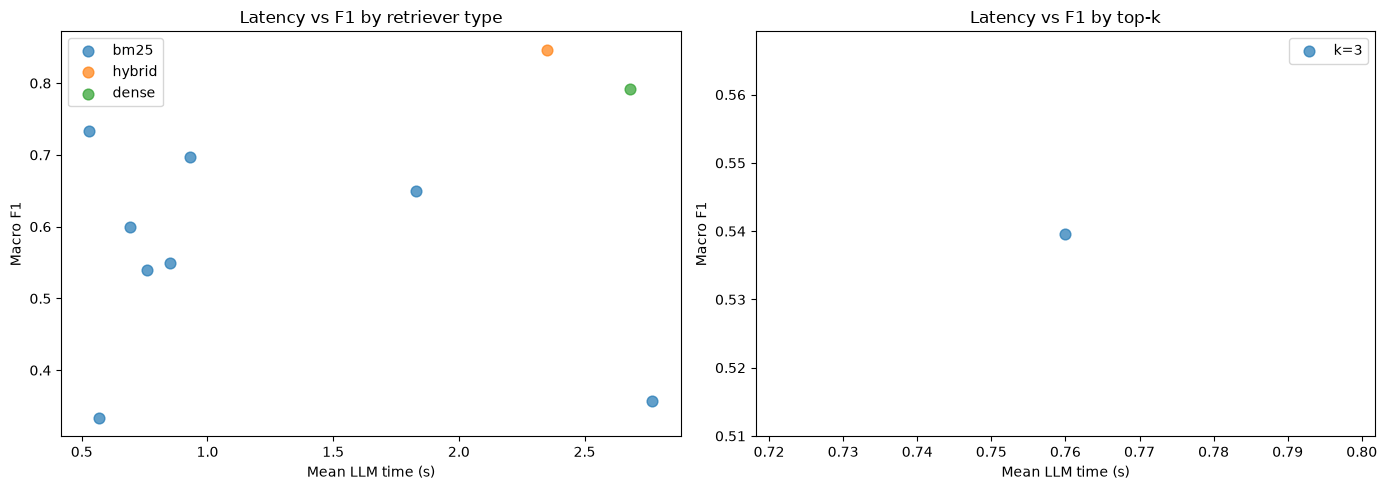

In [18]:
# CELL 15 — Latency vs F1 Plot
# Scatter plot comparing inference speed against classification accuracy.
# Helps identify configurations that are both fast and accurate —
# a configuration in the top-left is ideal (high F1, low latency).


fig, axes_arr = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — each retriever type gets its own colour
# shows whether retrieval method affects the speed/accuracy trade-off
for ret in CFG["retriever_types"]:
    sub = df_summary[df_summary["retriever"] == ret]
    axes_arr[0].scatter(sub["mean_llm_s"], sub["macro_f1"],
                        label=ret, alpha=0.7, s=60)
axes_arr[0].set_xlabel("Mean LLM time (s)")
axes_arr[0].set_ylabel("Macro F1")
axes_arr[0].set_title("Latency vs F1 by retriever type")
axes_arr[0].legend()

# Right plot — each top-k value gets its own colour
# shows whether retrieving more chunks improves F1 at the cost of speed
for k in CFG["top_k_values"]:
    sub = df_summary[df_summary["top_k"] == k]
    axes_arr[1].scatter(sub["mean_llm_s"], sub["macro_f1"],
                        label=f"k={k}", alpha=0.7, s=60)
axes_arr[1].set_xlabel("Mean LLM time (s)")
axes_arr[1].set_ylabel("Macro F1")
axes_arr[1].set_title("Latency vs F1 by top-k")
axes_arr[1].legend()

plt.tight_layout()
plt.show()

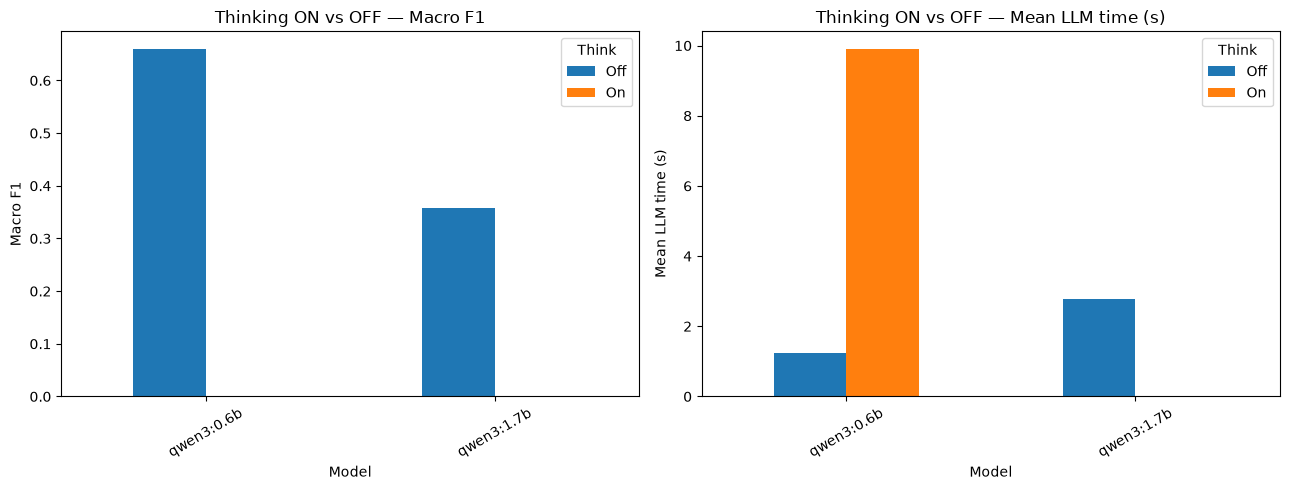

In [19]:
# CELL 16 — Thinking Mode Comparison Plot
# Bar chart comparing thinking ON vs OFF across models for two metrics:
#   Left  — macro F1 (does thinking improve accuracy?)
#   Right — mean LLM time (how much slower is thinking mode?)

# Summarise results grouped by model and thinking mode
think_summary = summarise(df_results, ["model", "think"])

fig, axes_arr = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes_arr,
    ["macro_f1",    "mean_llm_s"],
    ["Macro F1",    "Mean LLM time (s)"],
):
    # Pivot so rows=models, columns=think on/off — makes bar chart easy to plot
    pivot = think_summary.pivot(index="model", columns="think", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Thinking ON vs OFF — {title}")
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    ax.legend(title="Think", labels=["Off", "On"])
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Best configuration:
model          qwen3:0.6b
retriever          hybrid
top_k                   5
prompt_type     zero_shot
think               False
accuracy             0.85
macro_f1           0.8465
mean_llm_s           2.35


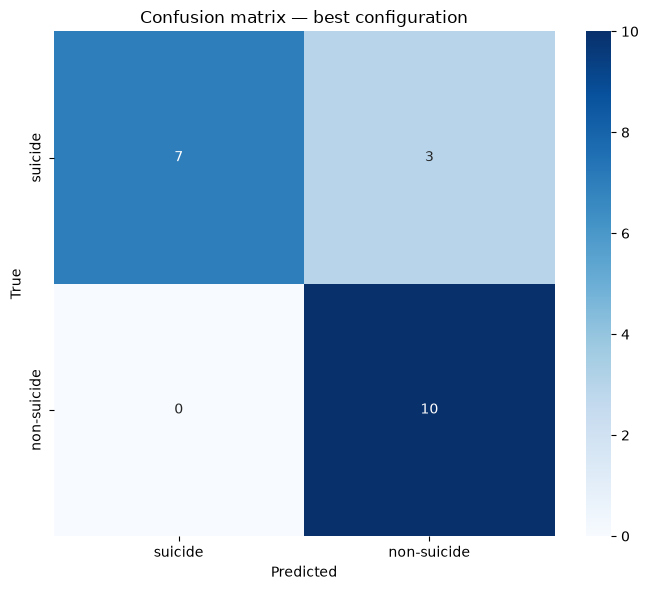


Classification report:
              precision    recall  f1-score   support

     suicide       1.00      0.70      0.82        10
 non-suicide       0.77      1.00      0.87        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



In [20]:
# CELL 17 — Best Configuration Analysis
# Identifies the best performing configuration by macro-F1 and produces:
#   - A confusion matrix showing where the model makes errors
#   - A full classification report with per-class precision, recall, F1
# The confusion matrix is particularly useful for spotting if the model
# confuses adjacent severity levels (e.g. mild vs moderate) more than
# distant ones (e.g. minimum vs severe), which is clinically expected.


# df_summary is sorted by macro_f1 descending so iloc[0] is the best config
best_row = df_summary.iloc[0]
print("Best configuration:")
print(best_row[["model","retriever","top_k","prompt_type","think",
                "accuracy","macro_f1","mean_llm_s"]].to_string())

# Filter raw results to only rows matching the best configuration
mask = (
    (df_results["model"]       == best_row["model"]) &
    (df_results["retriever"]   == best_row["retriever"]) &
    (df_results["top_k"]       == best_row["top_k"]) &
    (df_results["prompt_type"] == best_row["prompt_type"]) &
    (df_results["think"]       == best_row["think"])
)
best_df = df_results[mask]

# Confusion matrix — rows are true labels, columns are predicted labels
# diagonal = correct predictions, off-diagonal = errors
cm = confusion_matrix(best_df["true_label"], best_df["predicted"],
                      labels=CFG["labels"])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CFG["labels"], yticklabels=CFG["labels"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — best configuration")
plt.tight_layout()
plt.show()

# Per-class breakdown — shows which severity levels are hardest to classify
print("\nClassification report:")
print(classification_report(best_df["true_label"], best_df["predicted"],
                             labels=CFG["labels"], zero_division=0))

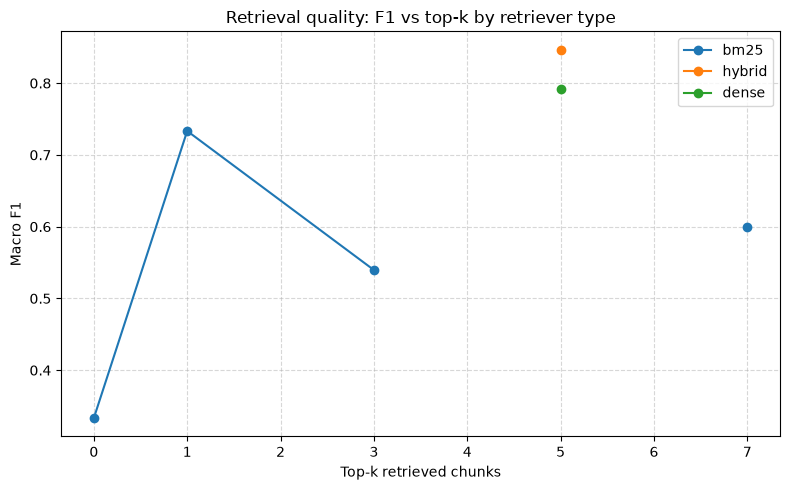

In [21]:
# CELL 18 — Top-k Sweep Plot
# Line chart showing how F1 changes as more chunks are retrieved (k=1,3,5,7)
# for each retriever type. Helps answer RQ1 — what is the optimal k?
# Expected pattern: F1 improves with k up to a point then plateaus or drops
# as irrelevant chunks start adding noise to the prompt.


# Summarise grouped by retriever and top-k
topk_summary = summarise(df_results, ["retriever", "top_k"])

fig, ax = plt.subplots(figsize=(8, 5))

# One line per retriever — sorted by k so the line plots left to right
for ret in CFG["retriever_types"]:
    sub = topk_summary[topk_summary["retriever"] == ret].sort_values("top_k")
    ax.plot(sub["top_k"], sub["macro_f1"], marker="o", label=ret)

ax.set_xlabel("Top-k retrieved chunks")
ax.set_ylabel("Macro F1")
ax.set_title("Retrieval quality: F1 vs top-k by retriever type")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

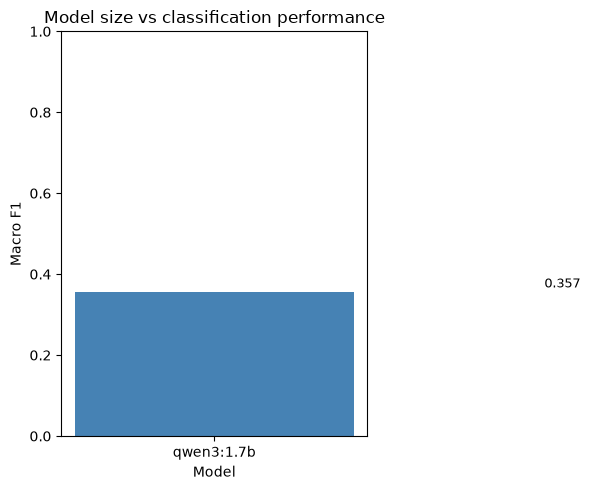

In [22]:
# CELL 19 — Model Size vs Performance Plot
# Bar chart comparing macro-F1 across model sizes (0.6b vs 1.7b).
# Answers RQ2 — does a larger model classify depression severity better?
# F1 values are annotated on top of each bar for easy reading.

# Summarise grouped by model only — averages across all other variables
model_summary = summarise(df_results, ["model"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_summary["model"], model_summary["macro_f1"], color="steelblue")
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.set_title("Model size vs classification performance")
ax.set_ylim(0, 1)

# Annotate each bar with its exact F1 value
for i, row in model_summary.iterrows():
    ax.text(i, row["macro_f1"] + 0.01, f"{row['macro_f1']:.3f}",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# CELL 20 — Save Results and Error Analysis
# Saves two CSV files and prints a sample of misclassified posts:
#   binary_summary.csv        — aggregated metrics per configuration
#   binary_error_analysis.csv — posts the best configuration got wrong
# The error analysis is useful for qualitative review — checking whether
# misclassifications are reasonable (e.g. mild predicted as moderate)
# or severe errors (e.g. minimum predicted as severe).

# Save the full summary table — one row per configuration
df_summary.to_csv(BINARY_RESULTS_SUMMARY_PATH, index=False)
print("Summary saved to", BINARY_RESULTS_SUMMARY_PATH)

# Extract misclassified posts from the best configuration for error analysis
errors = best_df[best_df["correct"] == 0][
    ["true_label", "predicted", "answer_text", "chunk_ids"]
].reset_index(drop=True)
_err_path = BINARY_ERROR_ANALYSIS_PATH
errors.to_csv(_err_path, index=False)
print(f"Error analysis: {len(errors)} misclassified posts saved to {_err_path}")

# Print a sample of errors — shows true label, predicted label, and model output
# chunk_ids shows which CDDR chunks were retrieved — useful for checking
# whether wrong predictions were caused by poor retrieval
print("\nSample errors:")
for _, r in errors.head(5).iterrows():
    print(f"  true={r['true_label']:8}  pred={r['predicted']:8}  output: {r['answer_text'][:80]}")

Summary saved to /Users/sidemoctardialla/Desktop/AI-group-project-2026/results/binary_summary.csv
Error analysis: 3 misclassified posts saved to /Users/sidemoctardialla/Desktop/AI-group-project-2026/results/binary_error_analysis.csv

Sample errors:
  true=suicide   pred=non-suicide  output: Label: non-suicide  
Reason: The post expresses distress and a desire to find me
  true=suicide   pred=non-suicide  output: Label: non-suicide  
Reason: The post expresses a sense of readiness to move for
  true=suicide   pred=non-suicide  output: Label: non-suicide  
Reason: The post describes a person who is experiencing a p
